# 06 — SHAP Analysis
Reuses `app.ml.shap_explainer` and the persisted model/explainer — identical to what `/api/explainability/*` serves.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../backend'))
import matplotlib.pyplot as plt
import pandas as pd
import joblib
from app.config import settings
from app.ml import shap_explainer, preprocessing
from app.ml.data_loader import load_raw_data
model = joblib.load(settings.model_path)
explainer = joblib.load(settings.shap_path)
columns = joblib.load(settings.feature_columns_path)
df = load_raw_data()
data = preprocessing.prepare_dataset(df)
X_sample = data['X_test'][:200]

C:\Users\91822\Downloads\risk_prediction\backend\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
importance = shap_explainer.global_feature_importance(explainer, X_sample, columns['feature_names'], top_n=15)
imp_df = pd.DataFrame(importance)
imp_df

,feature,mean_abs_shap
0,injury_count,0.22238
1,speed_work_sessions,0.16521
2,fatigue_score,0.10862
3,gender_Female,0.06288
4,stress_fatigue_index,0.06115
5,muscle_soreness,0.05396
6,training_frequency,0.04516
7,days_since_previous_injury,0.03340
8,age,0.02712
9,event_type_Middle Distance,0.01950


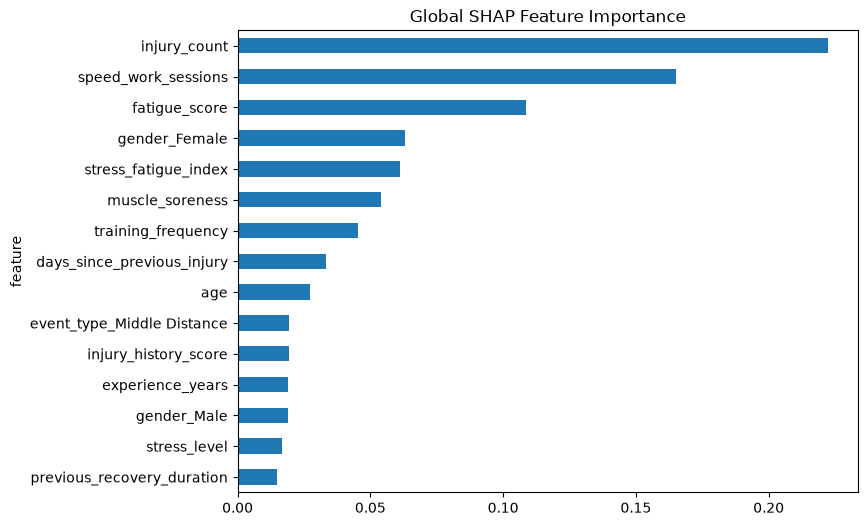

In [3]:
imp_df.plot(kind='barh', x='feature', y='mean_abs_shap', figsize=(8,6), legend=False)
plt.title('Global SHAP Feature Importance')
plt.gca().invert_yaxis()
plt.show()

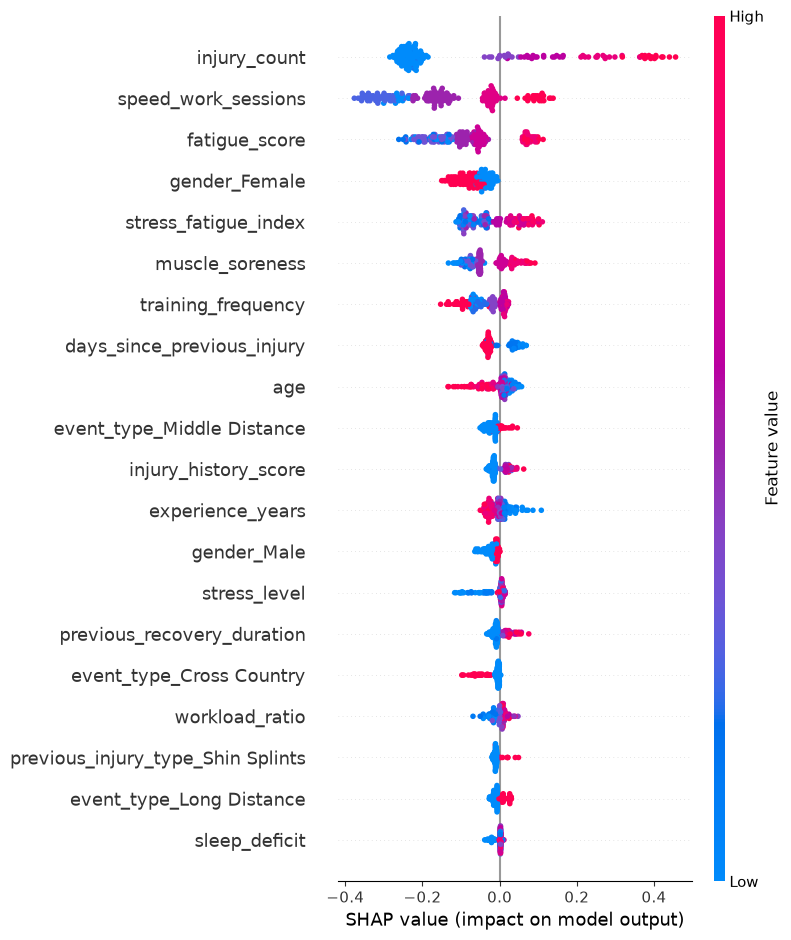

In [4]:
import shap
shap_values = explainer.shap_values(X_sample)
shap.summary_plot(shap_values, X_sample, feature_names=columns['feature_names'], show=True)